<h1 align = 'center'> Linear CLassification and Perceptrons </h1>

In this project, we will analyze the Perceptron algorithm and explore different techniques such as one-vs-one and one-vs-all for implementing multi-class classification. We will extend our analysis to cover the training process, the feature extraction methods, as well as more hybrid approaches. Finally, we will compare the results with the best performance achieved in our previous analysis of distance-based algorithms.

## Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

I0000 00:00:1776165687.501229   20148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776165687.534174   20148 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776165688.690583   20148 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Functions

#### Load dataset

In [2]:
def load_dataset() -> tuple :
    """
    Load the fashionMNIST dataset
    """
    
    fashion_mnist = tf.keras.datasets.fashion_mnist
    return fashion_mnist.load_data()

#### Visual Analysis

In [3]:
def plot_and_save_analysis(y_true, y_pred, x_test_images, name, class1_true,class1_pred,class2_true,class2_pred):
    """
    Create the confusion matrix and plot some True-False preidctions.
    """
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    
    cm_filename = f"confusion_matrix_{name}.svg"
    plt.savefig(cm_filename, format='svg', bbox_inches='tight')
    plt.close()

    correct_indices = np.where(y_true == y_pred)[0]
    wrong_6_as_0 = np.where((y_true == class1_true) & (y_pred == class1_pred))[0]
    wrong_4_as_2 = np.where((y_true == class2_true) & (y_pred == class2_pred))[0]



    
    if len(correct_indices) >= 2:
        
        c1, c2 = np.random.choice(correct_indices, 2, replace=False)
        
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        fig.suptitle(f'True Predictions', fontsize=14)

        axes[0].imshow(x_test_images[c1].reshape(28, 28), cmap='gray')
        axes[0].set_title(f"True: {y_true[c1]} | Pred: {y_pred[c1]}")
        axes[0].axis('off')
        
        axes[1].imshow(x_test_images[c2].reshape(28, 28), cmap='gray')
        axes[1].set_title(f"True: {y_true[c2]} | Pred: {y_pred[c2]}")
        axes[1].axis('off')

        correct_filename = f"correct_examples_{name}.svg"
        plt.savefig(correct_filename, format='svg', bbox_inches='tight')
        plt.show() 
        

    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f'False Predictions', fontsize=14)

    if len(wrong_6_as_0) > 0:
        w1 = np.random.choice(wrong_6_as_0)
        axes[0].imshow(x_test_images[w1].reshape(28, 28), cmap='gray')
        axes[0].set_title(f"True: {class1_true} | Pred: {class1_pred}")
        axes[0].axis('off')
    else:
        axes[0].text(0.5, 0.5, "Not Found\nTrue=6, Pred=0!", ha='center')
        axes[0].axis('off')

    if len(wrong_4_as_2) > 0:
        w2 = np.random.choice(wrong_4_as_2)
        axes[1].imshow(x_test_images[w2].reshape(28, 28), cmap='gray')
        axes[1].set_title(f"True: {class2_true}  | Pred: {class2_pred} ")
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, "NOt Found\nTrue=4, Pred=2!", ha='center')
        axes[1].axis('off')

    wrong_filename = f"wrong_examples_{name}.svg"
    plt.savefig(wrong_filename, format='svg', bbox_inches='tight')
    plt.show() 


#### Batch generator

In [4]:
def _get_batches(X,y, batch_size):
    n_samples = X.shape[0]
    indices = np.arange(n_samples)

    np.random.shuffle(indices)

    for start_idx in range(0, n_samples, batch_size):
        end_idx = min(start_idx + batch_size, n_samples)
        batch_indices = indices[start_idx:end_idx]

        yield X[batch_indices], y[batch_indices]

#### Flattening

In [5]:
def flattening(X):
    """
    flat the 28x28 image to a 784 vector

    Args:
        X (_type_): the images set
    """

    return X.reshape(X.shape[0], -1)

#### Mean brightness per axis

In [6]:
def mean_per_axis(X):
    """
    Calculate the mean brightness per row and per column and concatenate.

    Args:
        X (_type_): the images set
    """

    mean_per_row = np.mean(X,axis=1)
    mean_per_col = np.mean(X,axis=2)

    return np.hstack([mean_per_row,mean_per_col])

#### Normalization

In [7]:
def norm(X_train, X_test):
    """
    Normalize the data using min-max or z-score.

    Args:
        X_train (_type_): the training set
        X_test (_type_): the test set
    """
    x_train_embeddings = X_train.astype(float) / 255.0
    x_test_embeddings = X_test.astype(float) / 255.0

    return x_train_embeddings, x_test_embeddings

#### Evaluation

In [8]:
def evaluation(y_pred,y_true):
    """
    Print an evaluation report using the metrics accuracy,macro precision

    Args:
        y_pred (_np.ndarray): the labels the model predicted
        y_true (np.ndarray): the real labels
    """
    # Confusion Matrix
    cm = confusion_matrix(y_true,y_pred)
    display = ConfusionMatrixDisplay(confusion_matrix=cm)
    acc = accuracy_score(y_true,y_pred)
    macro_pre = precision_score(y_true,y_pred, average='macro')
    print(f" Accuracy Score: {acc}")
    print(f" Recall per class: {recall_score(y_true,y_pred,average=None)}")
    print(f" Precision per class: {precision_score(y_true,y_pred,average=None)}")
    print(f" Macro Precision: {macro_pre}")

    display.plot()
    plt.show()

    return acc, macro_pre

## Models Classes

### Perceptron

The original implementation of perceptron. 

No gradient descent, update weights per 1 batch. Step Function. No Regularization. Error = y_pred-y

In [9]:
class Perceptron:
    def __init__(self, epochs: int, mode: str = "standard"):
        self.epochs = epochs
        self.mode = mode

    def fit(self, x_train, y_train, x_val=None, y_val=None, weight = np.ones(2)):
        np.random.seed(42)
        training_procces_print = ""
       
        self.weights = np.array([[0.0] * (x_train.shape[1] + 1)])
        
        ones_t = np.ones((x_train.shape[0], 1))
        x_train = np.hstack((ones_t, x_train))
        
        if x_val is not None and y_val is not None:
            ones_v = np.ones((x_val.shape[0], 1))
            x_val = np.hstack((ones_v, x_val))

        train_loss = []
        val_loss = []
        learning_rate = 1e-4


        # Average Perceptron
        avg_weights = np.zeros_like(self.weights)
        total_steps = 0

        # Pocket Perceptron
        best_val_loss = float("inf")
        best_weights = np.copy(self.weights)


        training_procces_print += "Start Training\n"
        for i in range(self.epochs):
            total_train_loss = 0
            for (x_batch, y_batch) in _get_batches(x_train, y_train, 1):
                y_pred = self.predict(x_batch, add_bias=False)
                error = y_batch[0] - y_pred

                total_train_loss += np.abs(error).item()
                update = x_batch * error
                self.weights = self.weights + (learning_rate * update * weight[y_batch[0]])

                # Averaged logic
                if self.mode == "averaged":
                    avg_weights += self.weights
                total_steps+=1
                
            train_loss.append((total_train_loss / x_train.shape[0]))

            if x_val is not None and y_val is not None:
                total_val_loss = 0
                for (x_batch, y_batch) in _get_batches(x_val, y_val, 1):
                    y_pred = self.predict(x_batch, add_bias=False)
                    error = y_batch[0] - y_pred
                    total_val_loss += np.abs(error).item()
                    
                current_val_loss = total_val_loss / x_val.shape[0]
                val_loss.append(current_val_loss)

                # Pocket logic
                if self.mode == "pocket":
                    if current_val_loss < best_val_loss:
                        best_val_loss = current_val_loss
                        best_weights = np.copy(self.weights)
                training_procces_print += f'Epoch: {i}, train_loss = {train_loss[i]:.4f}, val_loss = {val_loss[i]:.4f}\n'
            else:
                training_procces_print += f'Epoch: {i}, train_loss = {train_loss[i]:.4f}\n'
                

        if self.mode == "averaged":
            self.weights = avg_weights/total_steps
        elif self.mode == "pocket" and x_val is not None:
            self.weights = best_weights
            
        return train_loss, val_loss, training_procces_print


    def predict(self, X_input, add_bias=True):
        if add_bias and self.weights.shape[1] != X_input.shape[1]: 
            ones_t = np.ones((X_input.shape[0], 1))
            X_input = np.hstack((ones_t, X_input))
            
        z = X_input @ self.weights.T
        y_pred = np.where(z >= 0, 1, 0)
        return y_pred
    
    def predict_proba(self, X_input, add_bias=True):
        if add_bias and self.weights.shape[1] != X_input.shape[1]: 
            ones_t = np.ones((X_input.shape[0], 1))
            X_input = np.hstack((ones_t, X_input))
            
        z = X_input @ self.weights.T
        return z

### One vs One

In [10]:
class One_vs_One:
    def __init__(self, epochs: int, mode = "standard"):
        self.models = {}
        self.mode = mode
        self.epochs = epochs

    def fit(self, x_train, y_train, weights = np.ones(10)):
        for i in range(10):
            for j in range(i + 1, 10):
                #Boolean Masking
                mask = np.isin(y_train, [i, j])
                x_train_set = x_train[mask]
                y_train_set = y_train[mask]
                
                # Relabeling:class i is 1, class j is 0
                y_train_set = np.where(y_train_set == i, 1, 0)

                w0 = weights[j]
                w1 = weights[i]
                a_perceptron = Perceptron(epochs=self.epochs, mode=self.mode)
                a_perceptron.fit(x_train_set, y_train_set,weight=np.array([w0,w1])) # x_val, y_val default None

                self.models[(i, j)] = a_perceptron

    def predict(self, x_input):
        n_samples = x_input.shape[0]
        
        votes = np.zeros((n_samples, 10))
        scores = np.zeros((n_samples, 10))

        for (class_pos, class_neg), a_model in self.models.items():
            
            y_pred = a_model.predict(x_input).flatten()
            z = a_model.predict_proba(x_input).flatten()

            mask_pos = (y_pred == 1)
            mask_neg = (y_pred == 0)

            votes[mask_pos, class_pos] += 1
            votes[mask_neg, class_neg] += 1

         
            scores[:, class_pos] += z
            scores[:, class_neg] -= z

        # Find the most voted classes
        # if there is a tie we add a small percentage of the score
        best_y = np.argmax(votes + 1e-4 * scores, axis=1)
    
        return best_y

### One vs All

In [11]:
class One_vs_All:
    def __init__(self, epochs, mode = "standard"):
        self.epochs = epochs
        self.mode = mode
        self.models = {}


    def fit(self,x_train,y_train,weights=np.ones(10)):
        
        for i in range(10):
            mask = np.isin(y_train, i)
            model_y_train = np.array(mask, dtype=int)
            a_perceptron = Perceptron(self.epochs,mode=self.mode)

            binary_weights = np.array([1.0 , weights[i]])
            a_perceptron.fit(x_train,model_y_train,weight=binary_weights)
            self.models[i] = a_perceptron

    def predict(self, x_input):

        n_samples = x_input.shape[0]
        scores = np.zeros((n_samples,10))

        for position,model in self.models.items():
            z = model.predict_proba(x_input).flatten()
            scores[:,position] += z

        best_y = np.argmax(scores,axis=1)

        return best_y
            

### Multiclass Perceptron

In [12]:
class multiPerceptron:
    def __init__(self, epochs, mode = "standard"):
        self.epochs = epochs
        self.mode = mode

    def fit(self, x_train, y_train, x_val=None, y_val = None, weights = np.ones(10)):

        np.random.seed(42)
        training_procces_print = ""

        self.weights = np.zeros((10, x_train.shape[1] + 1))

        # --- Averaged Mode ---
        avg_weights = np.zeros_like(self.weights)
        total_steps = 0
        
        # --- Pocket Mode ---
        best_val_loss = float('inf')
        best_weights = np.copy(self.weights)

        ones_t = np.ones((x_train.shape[0], 1))
        x_train = np.hstack((ones_t,x_train))

        if x_val is not None and y_val is not None:
            ones_v = np.ones((x_val.shape[0], 1))
            x_val = np.hstack((ones_v, x_val))

        train_loss = []
        val_loss = []
        learning_rate = 1e-2

        training_procces_print += "Start Training\n"
        for i in range(self.epochs):
            total_train_loss = 0
            for (x_batch,y_batch) in _get_batches(x_train, y_train, 1):
                y_pred = self.predict(x_batch, add_bias = False)[0]
                y_true = y_batch[0]

                if y_true != y_pred:
                    total_train_loss +=1
                    sample_importance = weights[y_true]
                    # Correct Class weights improve
                    self.weights[y_true] += learning_rate*x_batch[0]*sample_importance

                    # Penalty to the wrong predicted class
                    self.weights[y_pred] -= learning_rate*x_batch[0]*sample_importance

                # --- AVERAGED LOGIC ---
                if self.mode == "averaged" or self.mode == "hybrid":
                    avg_weights += self.weights
                total_steps += 1

            train_loss.append(total_train_loss/x_train.shape[0])

            if x_val is not None and y_val is not None:
                total_val_loss = 0
                for (x_batch, y_batch) in _get_batches(x_val, y_val, 1):
                    y_pred = self.predict(x_batch, add_bias=False)[0]
                    if y_batch[0] != y_pred:
                        total_val_loss +=1
                    
                current_val_loss = total_val_loss / x_val.shape[0]
                val_loss.append(current_val_loss)
                
                # --- POCKET LOGIC ---
                if self.mode == "pocket" or self.mode == "hybrid":
                    if current_val_loss < best_val_loss:
                        best_val_loss = current_val_loss
                        best_weights = np.copy(self.weights)
                training_procces_print += f'Epoch: {i}, train_loss = {train_loss[i]:.4f}, val_loss = {val_loss[i]:.4f}\n'
            else:
                training_procces_print += f'Epoch: {i}, train_loss = {train_loss[i]:.4f}\n'
                
        if self.mode == "averaged":
            self.weights = avg_weights / total_steps
        elif self.mode == "pocket" and x_val is not None:
            self.weights = best_weights
        elif self.mode == "hybrid":
            self.weights = ((avg_weights/total_steps) + best_weights) / 2

            
        return train_loss, val_loss, training_procces_print

    def predict(self, X_input, add_bias=True):
        if add_bias and self.weights.shape[1] != X_input.shape[1]: 
            ones_t = np.ones((X_input.shape[0], 1))
            X_input = np.hstack((ones_t, X_input))

        Z = X_input @ self.weights.T
        return np.argmax(Z,axis=1)


## Main

#### Load the dataset

In [14]:
(full_dataset, full_dataset_labels), (_,_) = load_dataset()

print(f"Dataset shape: {full_dataset.shape}")
print(f"Labels shape: {full_dataset_labels.shape}")

Dataset shape: (60000, 28, 28)
Labels shape: (60000,)


In [15]:
small_set_x , _ , small_set_y , _ = train_test_split(full_dataset,full_dataset_labels,train_size=10000,stratify=full_dataset_labels,random_state=42)
print(f"Small Dataset shape: {small_set_x.shape}")
print(f"Small Dataset Labels shape: {small_set_y.shape}")

Small Dataset shape: (10000, 28, 28)
Small Dataset Labels shape: (10000,)


In [16]:
x_train0 ,  x_temp , y_train0 , y_temp = train_test_split(small_set_x, small_set_y, train_size=0.7, stratify=small_set_y,random_state=42)
x_test0 , x_val0 , y_test0 , y_val0 = train_test_split(x_temp, y_temp, train_size=0.5, stratify=y_temp,random_state=42)

In [17]:
print(f"Training set class bincount: {np.bincount(y_train0)}")
print(f"Test set class bincount: {np.bincount(y_test0)}")
print(f"Validation set class bincount: {np.bincount(y_val0)}")

Training set class bincount: [700 700 700 700 700 700 700 700 700 700]
Test set class bincount: [150 150 150 150 150 150 150 150 150 150]
Validation set class bincount: [150 150 150 150 150 150 150 150 150 150]


### Basic Preproccesing

In [18]:
x_train_flat = flattening(x_train0)
x_test_flat = flattening(x_test0)
x_val_flat = flattening(x_val0)

In [19]:
x_train_flat, x_test_flat  = norm(x_train_flat, x_test_flat)
x_val_flat , _ = norm(x_val_flat,x_val_flat)

## Use the basic/original perceptron

In [68]:
x_train_class1, y_train_class1 = x_train_flat[y_train0 == 0], y_train0[y_train0==0]
x_train_class6, y_train_class6 = x_train_flat[y_train0 == 1], y_train0[y_train0==1]
x_1vs6 = np.concatenate((x_train_class1,x_train_class6))
y_1vs6 = np.concatenate((y_train_class1,y_train_class6))

n_samples = x_1vs6.shape[0]
indices = np.arange(n_samples)
np.random.seed(42)
np.random.shuffle(indices)
x_1vs6 = x_1vs6[indices]
y_1vs6 = y_1vs6[indices]

In [69]:
x_train_1vs6,  x_temp_1vs6, y_train_1vs6, y_temp_1vs6 = train_test_split(x_1vs6, y_1vs6, train_size=0.8, stratify=y_1vs6,random_state=42)
x_test_1vs6 , x_val_1vs6 , y_test_1vs6 , y_val_1vs6 = train_test_split(x_temp_1vs6, y_temp_1vs6, train_size=0.5, stratify=y_temp_1vs6,random_state=42)


In [70]:
print(f"Training set class bincount: {np.bincount(y_train_1vs6)}")
print(f"Test set class bincount: {np.bincount(y_test_1vs6)}")
print(f"Validation set class bincount: {np.bincount(y_val_1vs6)}")

Training set class bincount: [560 560]
Test set class bincount: [70 70]
Validation set class bincount: [70 70]


In [74]:
epochs = 15
perceptron = Perceptron(epochs)
train_loss, val_loss , report = perceptron.fit(x_train_1vs6,y_train_1vs6,x_val_1vs6,y_val_1vs6,)
print(report)
y_pred_1vs6 = perceptron.predict(x_test_1vs6)

Start Training
Epoch: 0, train_loss = 0.0563, val_loss = 0.0214
Epoch: 1, train_loss = 0.0286, val_loss = 0.0214
Epoch: 2, train_loss = 0.0259, val_loss = 0.0429
Epoch: 3, train_loss = 0.0241, val_loss = 0.0214
Epoch: 4, train_loss = 0.0187, val_loss = 0.0143
Epoch: 5, train_loss = 0.0116, val_loss = 0.0143
Epoch: 6, train_loss = 0.0179, val_loss = 0.0357
Epoch: 7, train_loss = 0.0170, val_loss = 0.0143
Epoch: 8, train_loss = 0.0161, val_loss = 0.0143
Epoch: 9, train_loss = 0.0125, val_loss = 0.0143
Epoch: 10, train_loss = 0.0071, val_loss = 0.0143
Epoch: 11, train_loss = 0.0089, val_loss = 0.0143
Epoch: 12, train_loss = 0.0098, val_loss = 0.0143
Epoch: 13, train_loss = 0.0143, val_loss = 0.0143
Epoch: 14, train_loss = 0.0071, val_loss = 0.0143



 Accuracy Score: 0.9714285714285714
 Recall per class: [0.98571429 0.95714286]
 Precision per class: [0.95833333 0.98529412]
 Macro Precision: 0.9718137254901962


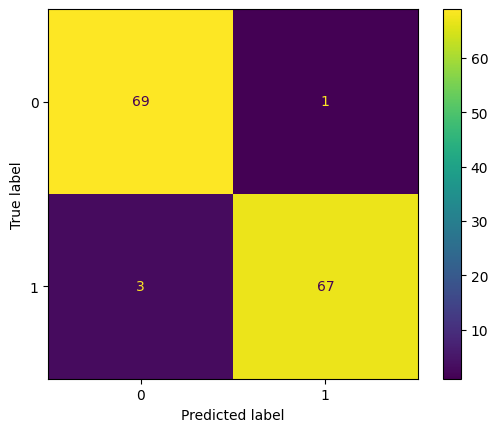

(0.9714285714285714, 0.9718137254901962)

In [75]:
evaluation(y_pred_1vs6,y_test_1vs6)

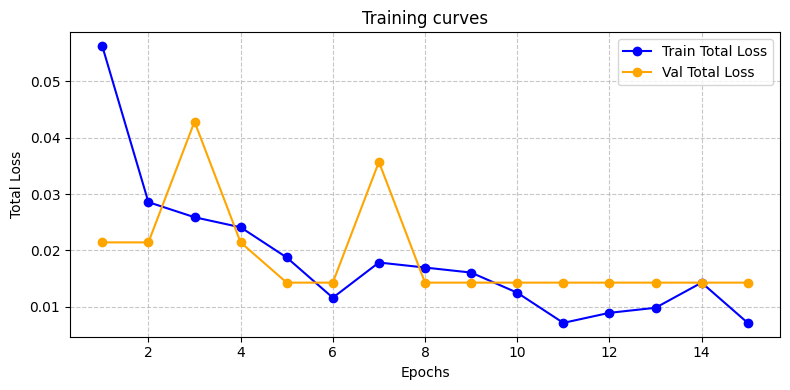

In [25]:
epochs_range = range(1, epochs + 1)


#(Train vs Val) 
plt.figure(figsize=(8,4))
plt.plot(epochs_range, train_loss, label='Train Total Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Val Total Loss', marker='o', color='orange')
plt.title('Training curves')
plt.xlabel('Epochs')
plt.ylabel('Total Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
#plt.savefig("single_perceptron.svg", format='svg', bbox_inches='tight')
plt.show()

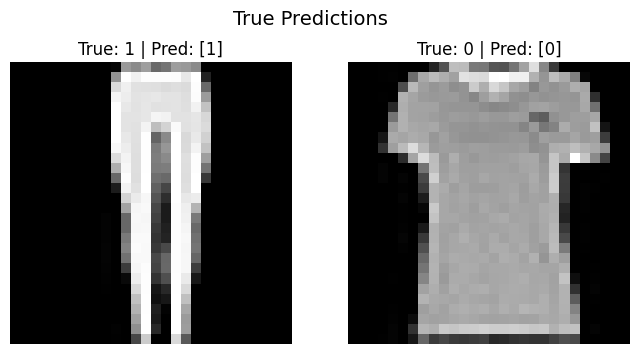

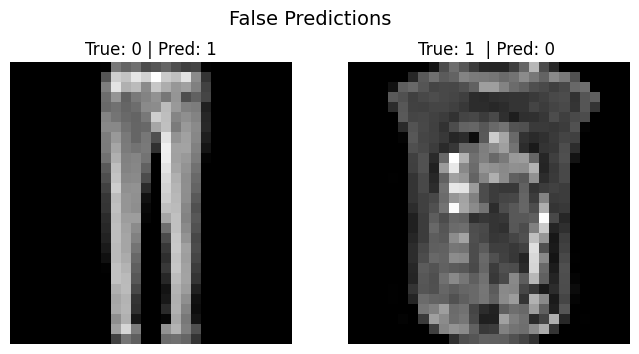

In [33]:
plot_and_save_analysis(y_test_1vs6,y_pred_1vs6,x_test_1vs6,"simple_perceptron",0,1,1,0)


# One vs One

## Basic Perceptron One vs One with flattening

We will create 45 perceptrons. Each perceptron will implement the prediction between two classes. The final label will be selected as the label with the majority of 'votes' from all the perceptrons

In [ ]:
# we will not use validation set so we concatenate the training and validation set
x_train_ovo = np.concatenate([x_train_flat,x_val_flat])
y_train_ovo = np.concatenate([y_train0,y_val0])

In [ ]:
ovo = One_vs_One(15)
ovo.fit(x_train_ovo,y_train_ovo)

y_pred = ovo.predict(x_test_flat)

 Accuracy Score: 0.7886666666666666
 Recall per class: [0.53333333 0.96       0.50666667 0.86       0.89333333 0.87333333
 0.48666667 0.94666667 0.96       0.86666667]
 Precision per class: [0.93023256 0.96       0.76767677 0.80625    0.55371901 0.94244604
 0.45061728 0.80225989 0.96644295 0.95588235]
 Macro Precision: 0.813552685416381


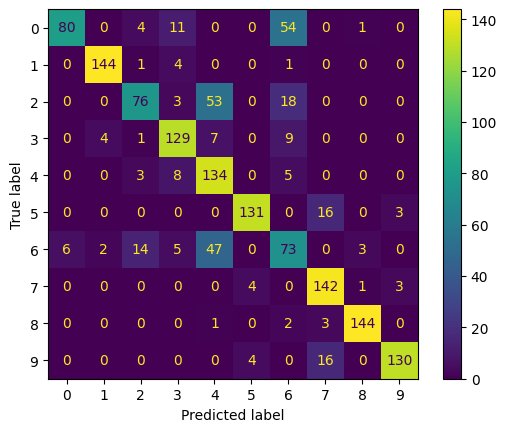

(0.7886666666666666, 0.813552685416381)

In [45]:
evaluation(y_pred,y_test0)

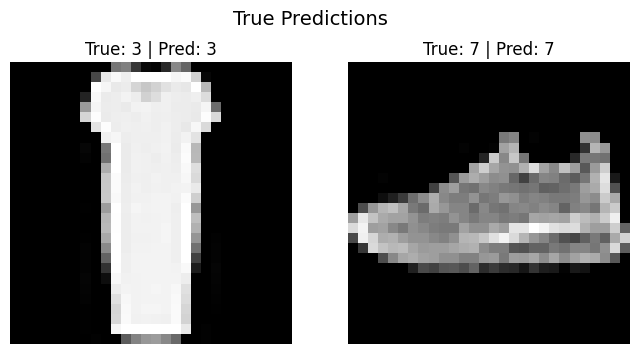

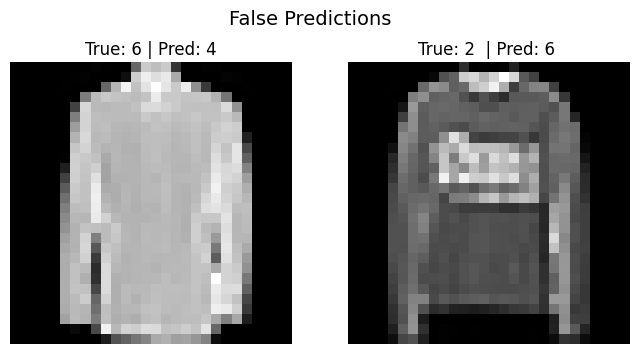

In [ ]:
plot_and_save_analysis(y_test0,y_pred,x_test_flat,"one_vs_one_basic_perceptron",6,4,2,6)

## One vs One using Mean brightness per axis

In [ ]:
# we will not use validation set so we concatenate the training and validation set
x_train_mpa = np.concatenate([x_train0,x_val0])
y_train_mpa = np.concatenate([y_train0,y_val0])

In [ ]:
x_train_mpa, x_test_mpa= norm(x_train_mpa,x_test0)

x_train_mpa = mean_per_axis(x_train_mpa)
x_test_mpa = mean_per_axis(x_test_mpa)

In [ ]:
ovo_mpa = One_vs_One(15)
ovo_mpa.fit(x_train_mpa,y_train_mpa)
y_pred_mpa = ovo_mpa.predict(x_test_mpa)

 Accuracy Score: 0.7986666666666666
 Recall per class: [0.84666667 0.94666667 0.77333333 0.68       0.56666667 0.9
 0.53333333 0.91333333 0.90666667 0.92      ]
 Precision per class: [0.65803109 0.95945946 0.61702128 0.91071429 0.72033898 0.91216216
 0.53333333 0.89542484 0.97142857 0.92      ]
 Macro Precision: 0.8097913996428613


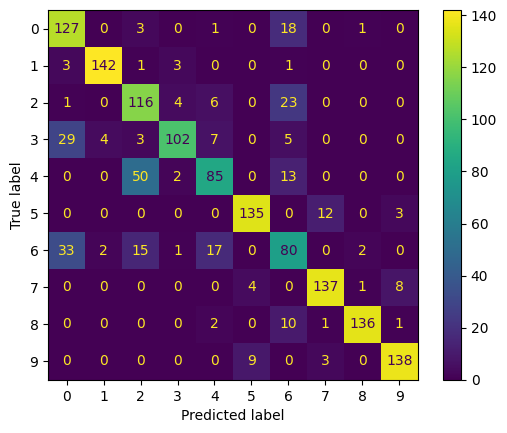

(0.7986666666666666, 0.8097913996428613)

In [ ]:
evaluation(y_pred_mpa,y_test0)

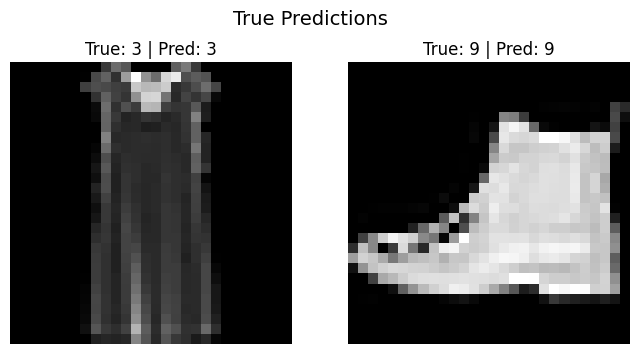

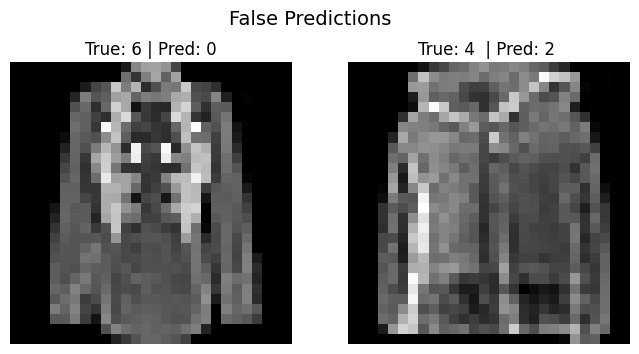

In [ ]:
plot_and_save_analysis(y_test0,y_pred_mpa,x_test_flat,"one_vs_one_basic_perceptron_mpa",6,0,4,2)

## One vs One using PCA

In [ ]:
# we will not use validation set so we concatenate the training and validation set
x_train_pca = np.concatenate([x_train0,x_val0])
y_train_pca = np.concatenate([y_train0,y_val0])

x_train_pca, x_test_pca= norm(x_train_pca,x_test0)

x_train_pca = flattening(x_train_pca)
x_test_pca = flattening(x_test_pca)

In [ ]:
pca = PCA(n_components=0.90)
x_train_pca = pca.fit_transform(x_train_pca)
x_test_pca = pca.transform(x_test_pca)

In [ ]:
ovo_pca = One_vs_One(15)
ovo_pca.fit(x_train_pca,y_train_pca)
y_pred_pca = ovo_pca.predict(x_test_pca)

 Accuracy Score: 0.8006666666666666
 Recall per class: [0.68666667 0.94       0.70666667 0.80666667 0.74       0.83333333
 0.54666667 0.94       0.92666667 0.88      ]
 Precision per class: [0.78030303 0.95918367 0.73103448 0.84615385 0.67272727 0.91240876
 0.48809524 0.80113636 0.95862069 0.92957746]
 Macro Precision: 0.8079240820711753


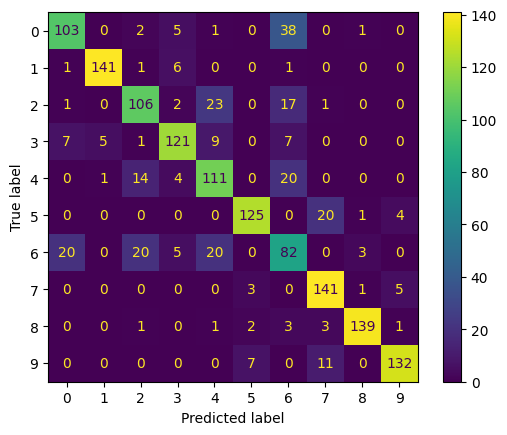

(0.8006666666666666, 0.8079240820711753)

In [ ]:
evaluation(y_pred_pca,y_test0)

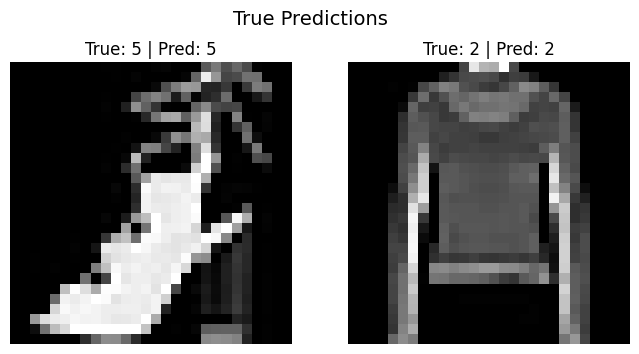

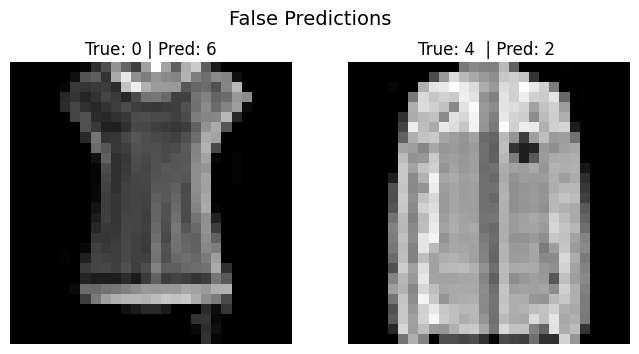

In [ ]:
plot_and_save_analysis(y_test0,y_pred_pca,x_test_flat,"one_vs_one_basic_perceptron_pca",0,6,4,2)

# One vs All

## Basic Perceptron One vs All

In [147]:
# we will not use validation set so we concatenate the training and validation set
x_train_ova = np.concatenate([x_train_flat,x_val_flat])
y_train_ova = np.concatenate([y_train0,y_val0])

In [ ]:
ova = One_vs_All(15)

ova.fit(x_train_ova,y_train_ova,weight=np.array([1,1]))
y_pred_ova = ova.predict(x_test_flat)

 Accuracy Score: 0.7826666666666666
 Recall per class: [0.59333333 0.96       0.44666667 0.80666667 0.86       0.90666667
 0.57333333 0.76       0.94666667 0.97333333]
 Precision per class: [0.88118812 0.92903226 0.79761905 0.85211268 0.58371041 0.90666667
 0.45502646 0.93442623 0.89873418 0.82022472]
 Macro Precision: 0.8058740755309234


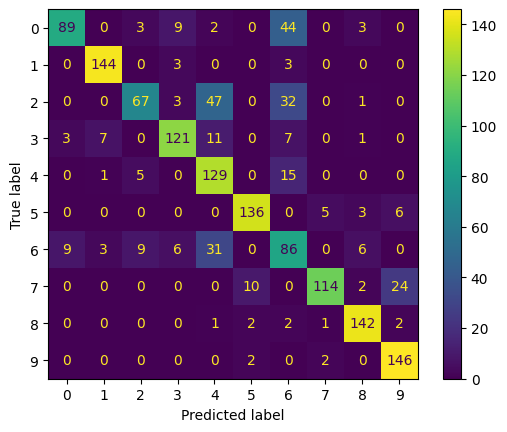

(0.7826666666666666, 0.8058740755309234)

In [149]:
evaluation(y_pred_ova,y_test0)

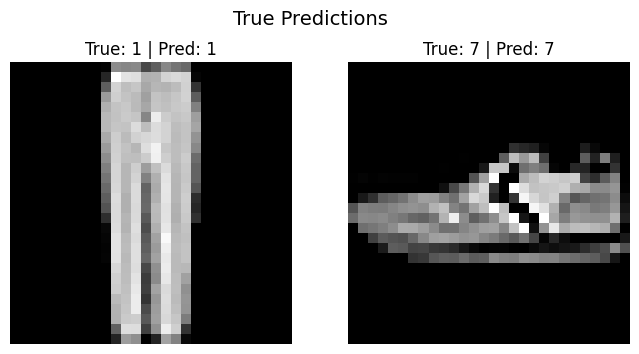

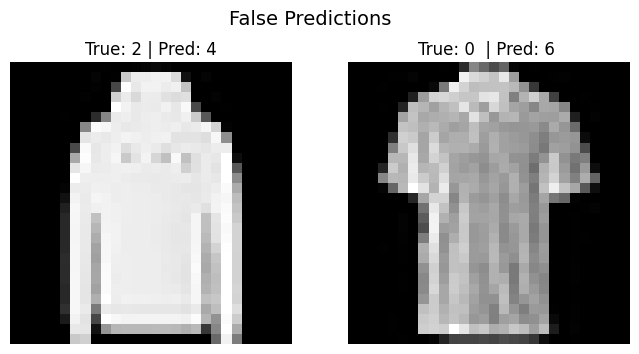

In [135]:
plot_and_save_analysis(y_test0,y_pred_ova,x_test_flat,"one_vs_all",2,4,0,6)

## One vs All using Mean Brightness

In [151]:
# we will not use validation set so we concatenate the training and validation set
x_train_mpa_ova = np.concatenate([x_train0,x_val0])
y_train_mpa_ova = np.concatenate([y_train0,y_val0])
x_train_mpa_ova, x_test_mpa_ova= norm(x_train_mpa_ova,x_test0)

x_train_mpa_ova = mean_per_axis(x_train_mpa_ova)
x_test_mpa_ova = mean_per_axis(x_test_mpa_ova)

In [ ]:
ova_mpa = One_vs_All(15)
ova_mpa.fit(x_train_mpa_ova,y_train_mpa_ova,weight=np.array([1,1]))
y_pred_mpa_ova = ova_mpa.predict(x_test_mpa_ova)

 Accuracy Score: 0.5653333333333334
 Recall per class: [0.00666667 0.92       0.01333333 0.8        0.         0.71333333
 0.91333333 0.8        0.72666667 0.76      ]
 Precision per class: [1.         0.97183099 1.         0.72289157 0.         0.856
 0.20980092 0.86330935 0.75694444 0.890625  ]
 Macro Precision: 0.7271402267979125


/home/dimitrios-pakakis/miniconda3/envs/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dimitrios-pakakis/miniconda3/envs/lab/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


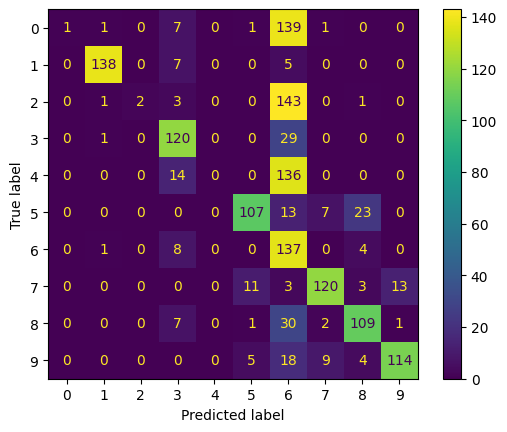

(0.5653333333333334, 0.7271402267979125)

In [153]:
evaluation(y_pred_mpa_ova,y_test0)

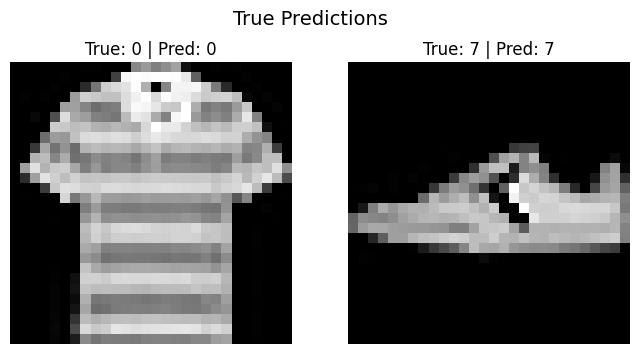

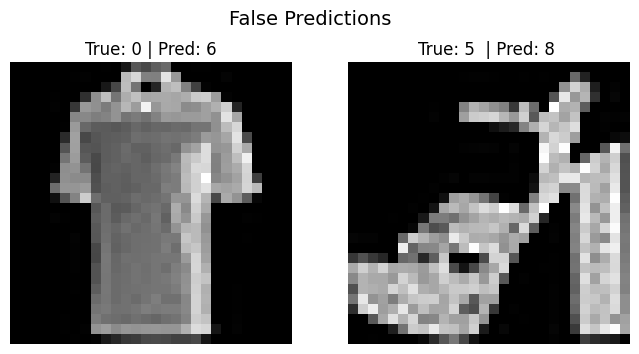

In [136]:
plot_and_save_analysis(y_test0,y_pred_mpa_ova,x_test_flat,"one_vs_all_mpa",0,6,5,8)

## One vs All using PCA

In [ ]:
# we will not use validation set so we concatenate the training and validation set
x_train_pca_ova = np.concatenate([x_train0,x_val0])
y_train_pca_ova = np.concatenate([y_train0,y_val0])

x_train_pca_ova, x_test_pca_ova= norm(x_train_pca_ova,x_test0)

x_train_pca_ova = flattening(x_train_pca_ova)
x_test_pca_ova = flattening(x_test_pca_ova)
pca_ova = PCA(n_components=0.95)
x_train_pca_ova = pca_ova.fit_transform(x_train_pca_ova)
x_test_pca_ova = pca_ova.transform(x_test_pca_ova)



In [157]:
ovo_pca_ova = One_vs_All(15)
ovo_pca_ova.fit(x_train_pca_ova,y_train_pca_ova,weight=np.array([1,1]))
y_pred_pca_ova = ovo_pca_ova.predict(x_test_pca_ova)

 Accuracy Score: 0.752
 Recall per class: [0.66666667 0.94       0.47333333 0.80666667 0.75333333 0.95333333
 0.58       0.59333333 0.82666667 0.92666667]
 Precision per class: [0.82644628 0.97241379 0.81609195 0.8013245  0.60106383 0.69417476
 0.47540984 0.90816327 0.90510949 0.75543478]
 Macro Precision: 0.7755632491529705


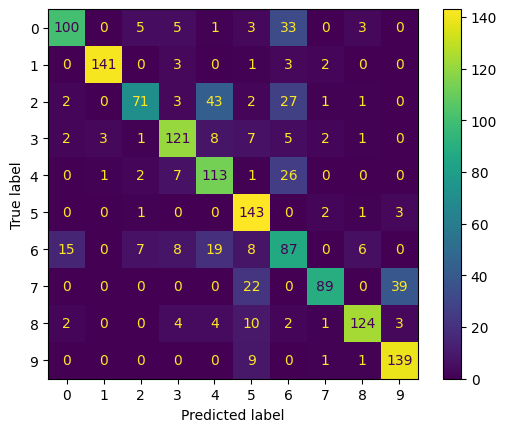

(0.752, 0.7755632491529705)

In [156]:
evaluation(y_pred_pca_ova,y_test0)

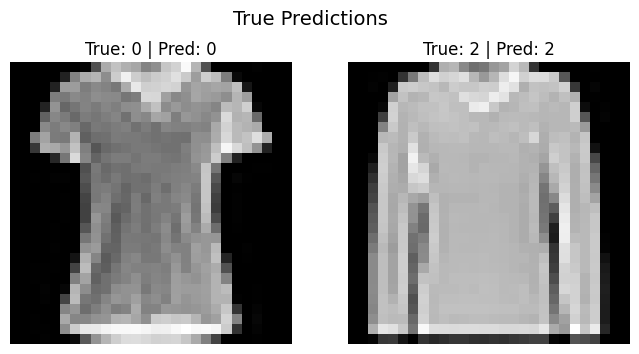

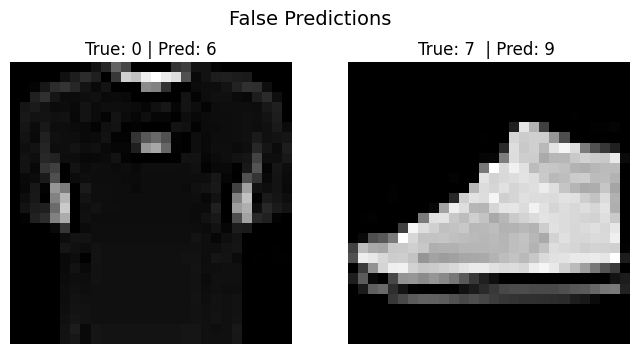

In [137]:
plot_and_save_analysis(y_test0,y_pred_pca_ova,x_test_flat,"one_vs_all_pca",0,6,7,9)

# Multi-class Perceptron

## Flattening

In [68]:
epochs = 15
multi_perceptron = multiPerceptron(epochs)
train_loss, val_loss , report = multi_perceptron.fit(x_train_flat,y_train0,x_val_flat,y_val0)
print(report)
y_pred_multiclass = multi_perceptron.predict(x_test_flat)

Start Training
Epoch: 0, train_loss = 0.3086, val_loss = 0.2587
Epoch: 1, train_loss = 0.2369, val_loss = 0.2500
Epoch: 2, train_loss = 0.2187, val_loss = 0.2347
Epoch: 3, train_loss = 0.2134, val_loss = 0.2833
Epoch: 4, train_loss = 0.1987, val_loss = 0.1973
Epoch: 5, train_loss = 0.1921, val_loss = 0.2327
Epoch: 6, train_loss = 0.1897, val_loss = 0.1907
Epoch: 7, train_loss = 0.1799, val_loss = 0.2300
Epoch: 8, train_loss = 0.1839, val_loss = 0.2160
Epoch: 9, train_loss = 0.1789, val_loss = 0.2547
Epoch: 10, train_loss = 0.1693, val_loss = 0.2120
Epoch: 11, train_loss = 0.1656, val_loss = 0.1960
Epoch: 12, train_loss = 0.1643, val_loss = 0.2800
Epoch: 13, train_loss = 0.1587, val_loss = 0.1793
Epoch: 14, train_loss = 0.1584, val_loss = 0.1947



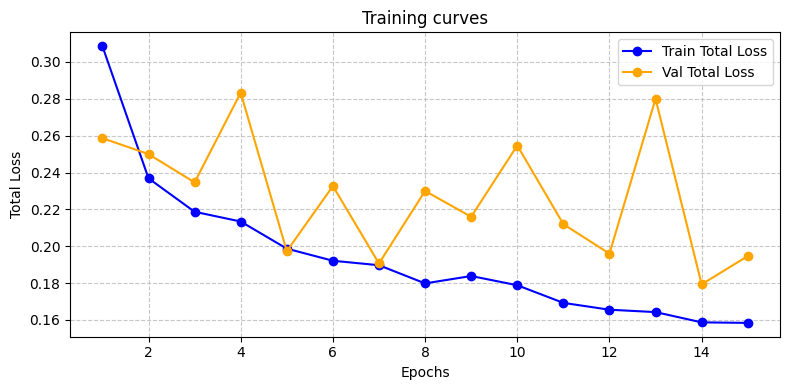

In [69]:
epochs_range = range(1, epochs + 1)


#(Train vs Val) 
plt.figure(figsize=(8,4))
plt.plot(epochs_range, train_loss, label='Train Total Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Val Total Loss', marker='o', color='orange')
plt.title('Training curves')
plt.xlabel('Epochs')
plt.ylabel('Total Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("multiclass_perceptron.svg", format='svg', bbox_inches='tight')
plt.show()

 Accuracy Score: 0.8
 Recall per class: [0.88666667 0.97333333 0.5        0.69333333 0.90666667 0.8
 0.42       0.92666667 0.95333333 0.94      ]
 Precision per class: [0.70744681 0.85882353 0.81521739 0.92035398 0.62100457 0.94488189
 0.5625     0.86335404 0.91082803 0.8757764 ]
 Macro Precision: 0.8080186627761776


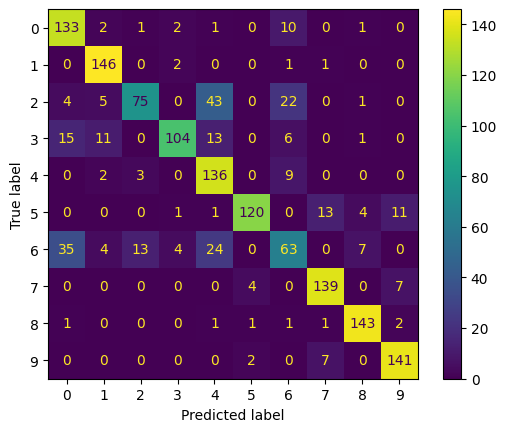

(0.8, 0.8080186627761776)

In [70]:
evaluation(y_pred_multiclass,y_test0)

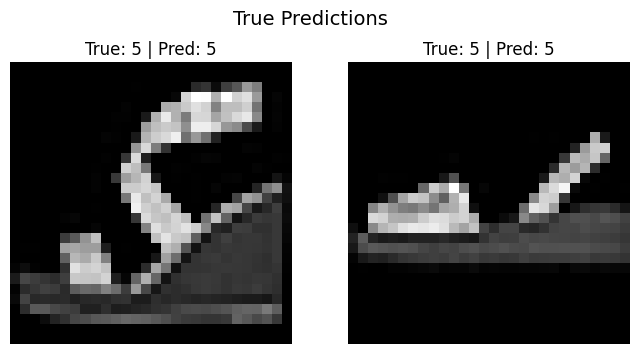

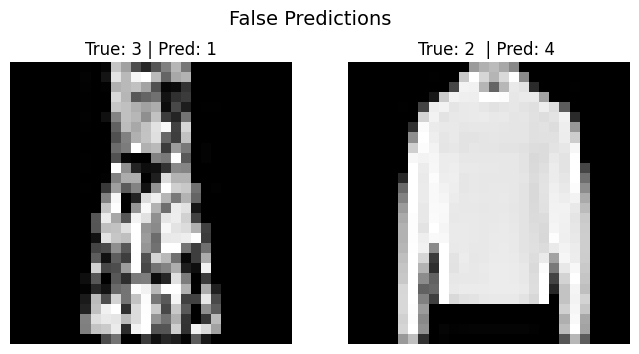

In [45]:
plot_and_save_analysis(y_test0,y_pred_multiclass,x_test_flat,"multiclass_perceptron,",3,1,2,4)

## Mean per Axis

In [39]:
x_train_mpa_mclass , x_val_mpa_mclass = norm(x_train0,x_val0)
x_test_mpa_mclass , _ = norm(x_test0,x_test0)

x_train_mpa_mclass = mean_per_axis(x_train_mpa_mclass)
x_val_mpa_mclass = mean_per_axis(x_val_mpa_mclass)
x_test_mpa_mclass = mean_per_axis(x_test_mpa_mclass)

In [41]:
epochs = 15
multi_perceptron_mpa = multiPerceptron(epochs)
train_loss, val_loss , report = multi_perceptron_mpa.fit(x_train_mpa_mclass,y_train0,x_val_mpa_mclass,y_val0)
print(report)
y_pred_multiclass_mpa = multi_perceptron_mpa.predict(x_test_mpa_mclass)

Start Training
Epoch: 0, train_loss = 0.4170, val_loss = 0.3533
Epoch: 1, train_loss = 0.3520, val_loss = 0.3393
Epoch: 2, train_loss = 0.3346, val_loss = 0.2907
Epoch: 3, train_loss = 0.3227, val_loss = 0.4127
Epoch: 4, train_loss = 0.3201, val_loss = 0.2907
Epoch: 5, train_loss = 0.3191, val_loss = 0.2707
Epoch: 6, train_loss = 0.3119, val_loss = 0.3080
Epoch: 7, train_loss = 0.3113, val_loss = 0.3893
Epoch: 8, train_loss = 0.3097, val_loss = 0.2933
Epoch: 9, train_loss = 0.3009, val_loss = 0.3087
Epoch: 10, train_loss = 0.3036, val_loss = 0.2560
Epoch: 11, train_loss = 0.3057, val_loss = 0.3053
Epoch: 12, train_loss = 0.2996, val_loss = 0.2927
Epoch: 13, train_loss = 0.3060, val_loss = 0.2773
Epoch: 14, train_loss = 0.2999, val_loss = 0.2387



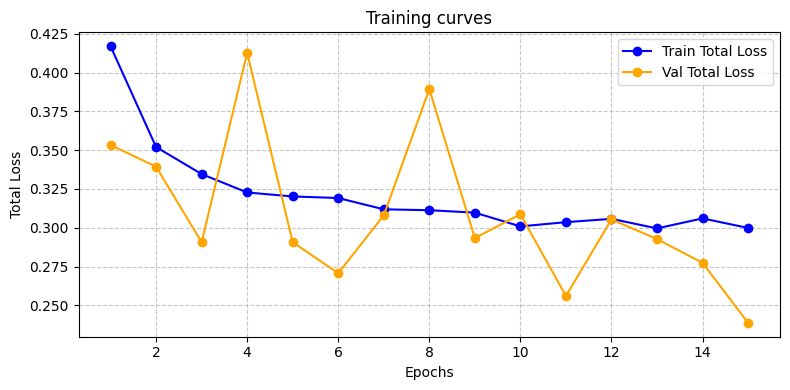

In [42]:
epochs_range = range(1, epochs + 1)


#(Train vs Val) 
plt.figure(figsize=(8,4))
plt.plot(epochs_range, train_loss, label='Train Total Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Val Total Loss', marker='o', color='orange')
plt.title('Training curves')
plt.xlabel('Epochs')
plt.ylabel('Total Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("multiclass_perceptron_mpa.svg", format='svg', bbox_inches='tight')
plt.show()

 Accuracy Score: 0.736
 Recall per class: [0.82       0.93333333 0.76       0.79333333 0.36       0.80666667
 0.2        0.9        0.91333333 0.87333333]
 Precision per class: [0.67582418 0.92105263 0.49350649 0.73006135 0.5        0.87681159
 0.56603774 0.77142857 0.88387097 0.91608392]
 Macro Precision: 0.7334677435909246


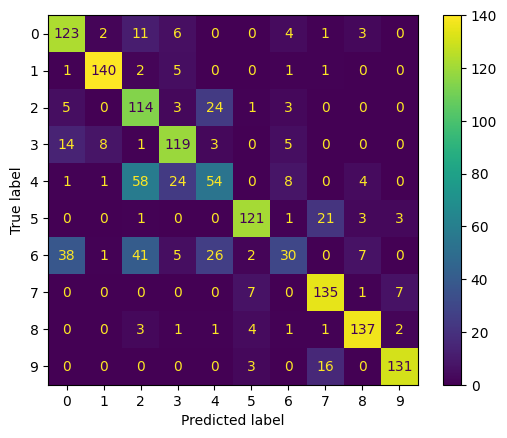

(0.736, 0.7334677435909246)

In [43]:
evaluation(y_pred_multiclass_mpa,y_test0)

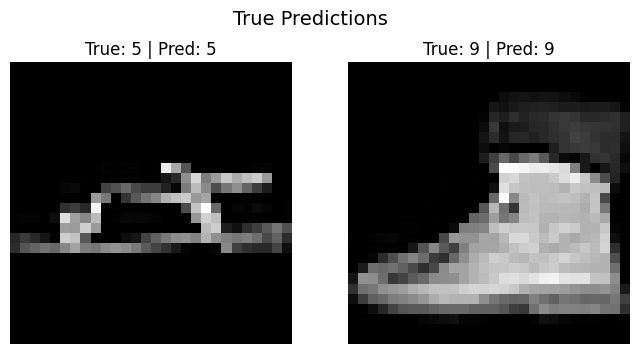

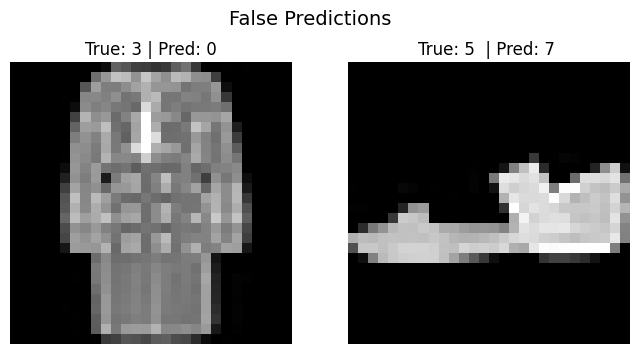

In [46]:
plot_and_save_analysis(y_test0,y_pred_multiclass_mpa,x_test_flat,"multiclass_perceptron_mpa,",3,0,5,7)

## PCA

In [51]:
pca_mclass = PCA(n_components=0.95)
x_train_pca_mclass = pca_mclass.fit_transform(x_train_flat)
x_val_pca_mclass = pca_mclass.transform(x_val_flat)
x_test_pca_mclass = pca_mclass.transform(x_test_flat)

In [52]:
epochs = 15
multi_perceptron_pca = multiPerceptron(epochs)
train_loss, val_loss , report = multi_perceptron_pca.fit(x_train_pca_mclass,y_train0,x_val_pca_mclass,y_val0)
print(report)
y_pred_multiclass_pca = multi_perceptron_pca.predict(x_test_pca_mclass)

Start Training
Epoch: 0, train_loss = 0.2704, val_loss = 0.2347
Epoch: 1, train_loss = 0.2267, val_loss = 0.2020
Epoch: 2, train_loss = 0.2176, val_loss = 0.2187
Epoch: 3, train_loss = 0.2101, val_loss = 0.2840
Epoch: 4, train_loss = 0.1997, val_loss = 0.2033
Epoch: 5, train_loss = 0.1959, val_loss = 0.2513
Epoch: 6, train_loss = 0.2026, val_loss = 0.2080
Epoch: 7, train_loss = 0.1896, val_loss = 0.2173
Epoch: 8, train_loss = 0.1954, val_loss = 0.2287
Epoch: 9, train_loss = 0.1881, val_loss = 0.2127
Epoch: 10, train_loss = 0.1881, val_loss = 0.2047
Epoch: 11, train_loss = 0.1917, val_loss = 0.2033
Epoch: 12, train_loss = 0.1880, val_loss = 0.2087
Epoch: 13, train_loss = 0.1814, val_loss = 0.2173
Epoch: 14, train_loss = 0.1807, val_loss = 0.2073



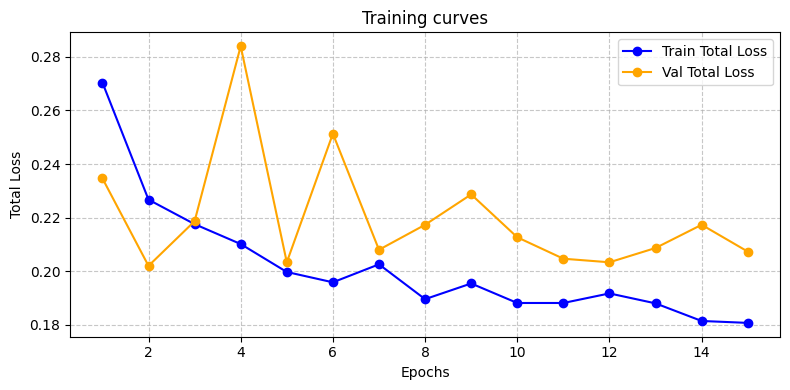

In [53]:
epochs_range = range(1, epochs + 1)


#(Train vs Val) 
plt.figure(figsize=(8,4))
plt.plot(epochs_range, train_loss, label='Train Total Loss', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Val Total Loss', marker='o', color='orange')
plt.title('Training curves')
plt.xlabel('Epochs')
plt.ylabel('Total Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("multiclass_perceptron_pca.svg", format='svg', bbox_inches='tight')
plt.show()

 Accuracy Score: 0.784
 Recall per class: [0.86       0.93333333 0.58       0.72       0.86       0.84666667
 0.36666667 0.94       0.91333333 0.82      ]
 Precision per class: [0.70491803 0.95890411 0.73109244 0.87096774 0.61722488 0.90070922
 0.48672566 0.77472527 0.91333333 0.92481203]
 Macro Precision: 0.7883412723377741


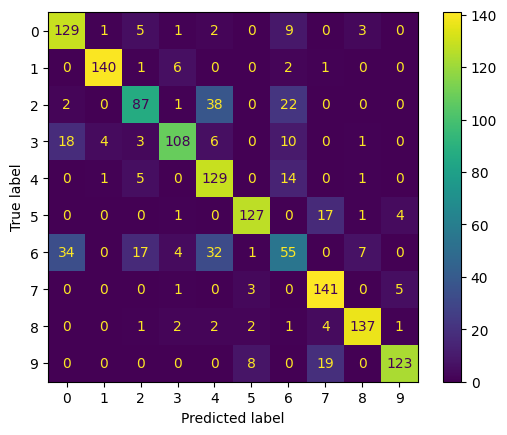

(0.784, 0.7883412723377741)

In [54]:
evaluation(y_pred_multiclass_pca,y_test0)

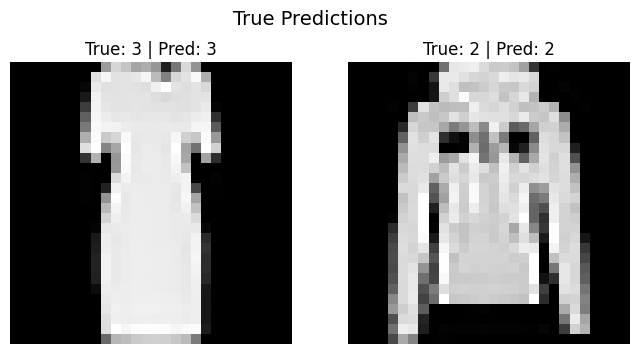

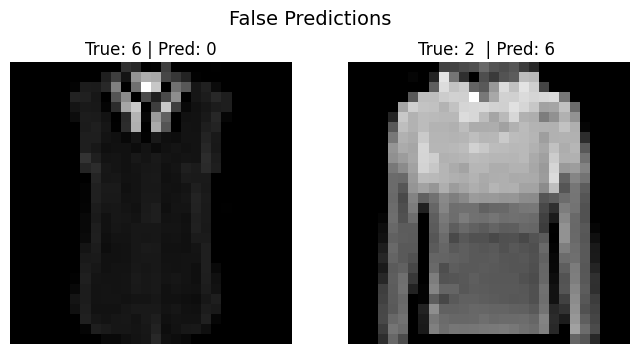

In [55]:
plot_and_save_analysis(y_test0,y_pred_multiclass_pca,x_test_flat,"multiclass_perceptron_pca",6,0,2,6)

# Best Technique using all dataset

In [13]:
(x_train_full , y_train_full) , (x_test_full , y_test_full) = load_dataset()

x_flat = flattening(x_test_full)

## One vs One using PCA 

 Accuracy Score: 0.8072
 Recall per class: [0.809 0.95  0.704 0.859 0.626 0.858 0.447 0.958 0.922 0.939]
 Precision per class: [0.76465028 0.96251266 0.63252471 0.80581614 0.69094923 0.95652174
 0.52962085 0.85765443 0.91559086 0.93432836]
 Macro Precision: 0.8050169264533376


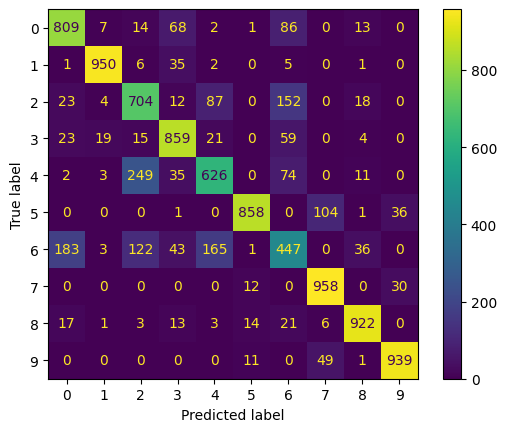

(0.8072, 0.8050169264533376)

In [64]:
x_train_full_pca, x_test_full_pca= norm(x_train_full,x_test_full)

x_train_full_pca = flattening(x_train_full_pca)
x_test_full_pca = flattening(x_test_full_pca)

pca = PCA(n_components=0.90)
x_train_full_pca = pca.fit_transform(x_train_full_pca)
x_test_full_pca = pca.transform(x_test_full_pca)

ovo_pca_full = One_vs_One(15)
ovo_pca_full.fit(x_train_full_pca,y_train_full)
y_pred_pca_full = ovo_pca_full.predict(x_test_full_pca)

evaluation(y_pred_pca_full,y_test_full)

## One vs All with flattening

 Accuracy Score: 0.8249
 Recall per class: [0.877 0.951 0.665 0.839 0.863 0.946 0.353 0.882 0.922 0.951]
 Precision per class: [0.7016     0.97239264 0.7455157  0.85264228 0.61642857 0.89413989
 0.67754319 0.94432548 0.95544041 0.93418468]
 Macro Precision: 0.8294212825855741


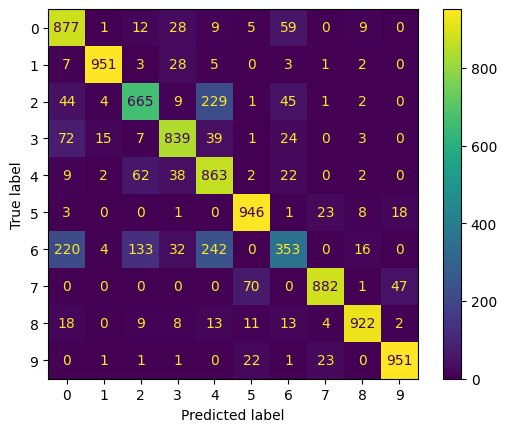

(0.8249, 0.8294212825855741)

In [65]:
x_train_full_ova_flat, x_test_full_ova_flat= norm(x_train_full,x_test_full)

x_train_full_ova_flat = flattening(x_train_full_ova_flat)
x_test_full_ova_flat = flattening(x_test_full_ova_flat)

ova_full = One_vs_All(15)

ova_full.fit(x_train_full_ova_flat,y_train_full,weight=np.array([1,1]))
y_pred_ova_full = ova_full.predict(x_test_full_ova_flat)

evaluation(y_pred_ova_full,y_test_full)

## Multiclass Perceptron with Flattening

 Accuracy Score: 0.8092
 Recall per class: [0.943 0.948 0.812 0.671 0.639 0.919 0.35  0.933 0.94  0.937]
 Precision per class: [0.56399522 0.97731959 0.64701195 0.89586115 0.77267231 0.93110436
 0.68493151 0.90319458 0.93625498 0.94455645]
 Macro Precision: 0.8256902086955892


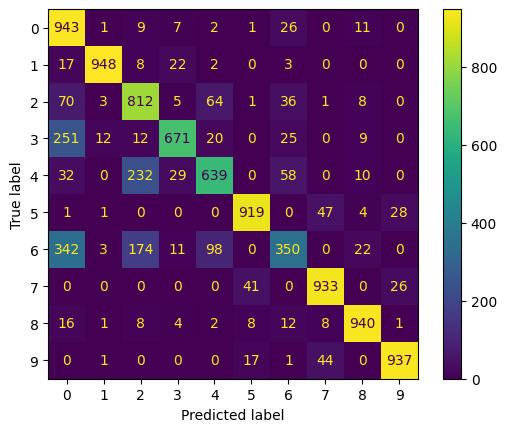

(0.8092, 0.8256902086955892)

In [66]:
x_train_full_mclass, x_test_full_mclass= norm(x_train_full,x_test_full)

x_train_full_mclass = flattening(x_train_full_mclass)
x_test_full_mclass = flattening(x_test_full_mclass)

multi_perceptron_full = multiPerceptron(epochs)
multi_perceptron_full.fit(x_train_full_mclass,y_train_full)
y_pred_full_multiclass = multi_perceptron_full.predict(x_test_full_mclass)

evaluation(y_pred_full_multiclass,y_test_full)

# Unbalanced Dataset

In [21]:
np.random.seed(42)

x_unbalanced_list = []
y_unbalanced_list = []

classes = np.unique(y_train_full)

for c in classes:
    indices = np.where(y_train_full == c)[0]
    
    np.random.shuffle(indices)
    
    if c == 6:
        n_samples = 1000
    else:
        n_samples = 50
        
    selected_indices = indices[:n_samples]
    
    x_unbalanced_list.append(x_train_full[selected_indices])
    y_unbalanced_list.append(y_train_full[selected_indices])

x_unbalanced_set = np.concatenate(x_unbalanced_list, axis=0)
y_unbalanced_set = np.concatenate(y_unbalanced_list, axis=0)

final_n_samples = x_unbalanced_set.shape[0]
final_indices = np.arange(final_n_samples)
np.random.shuffle(final_indices)

x_unbalanced_set = x_unbalanced_set[final_indices]
y_unbalanced_set = y_unbalanced_set[final_indices]

print(f"Total samples in unbalanced set: {x_unbalanced_set.shape[0]}")
print(f"Class distribution: {np.bincount(y_unbalanced_set)}")

Total samples in unbalanced set: 1450
Class distribution: [  50   50   50   50   50   50 1000   50   50   50]


## One vs One

 Accuracy Score: 0.6371
 Recall per class: [0.358 0.886 0.152 0.727 0.238 0.896 0.92  0.871 0.795 0.528]
 Precision per class: [0.91560102 0.99438833 0.64135021 0.8502924  0.75555556 0.80358744
 0.2647482  0.64806548 0.95209581 0.97416974]
 Macro Precision: 0.7799854186582567


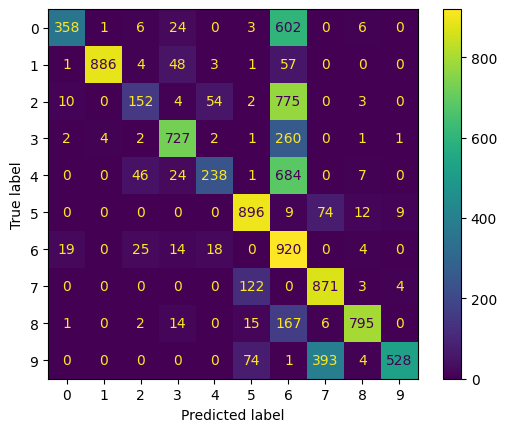

(0.6371, 0.7799854186582567)

In [73]:
x_train_ovo_unbalanced, x_test_ovo_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_ovo_unbalanced = flattening(x_train_ovo_unbalanced)
x_test_ovo_unbalanced = flattening(x_test_ovo_unbalanced)

pca = PCA(n_components=0.90)
x_train_ovo_unbalanced = pca.fit_transform(x_train_ovo_unbalanced)
x_test_ovo_unbalanced = pca.transform(x_test_ovo_unbalanced)

ovo_unbalanced = One_vs_One(15)
ovo_unbalanced.fit(x_train_ovo_unbalanced,y_unbalanced_set)
y_pred_unbalanced_ovo = ovo_unbalanced.predict(x_test_ovo_unbalanced)

evaluation(y_pred_unbalanced_ovo,y_test_full)

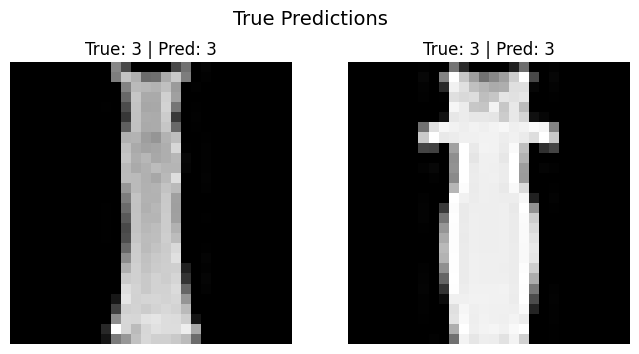

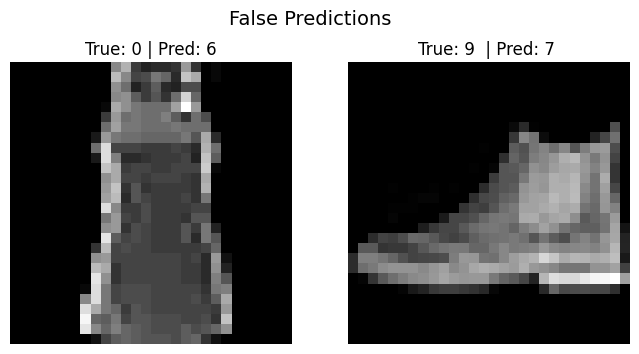

In [82]:
plot_and_save_analysis(y_test_full,y_pred_unbalanced_ovo,x_flat,"one_vs_one_unbalanced",0,6,9,7)

## One vs All

 Accuracy Score: 0.6633
 Recall per class: [0.372 0.897 0.325 0.68  0.135 0.763 0.928 0.907 0.799 0.827]
 Precision per class: [0.85321101 0.98140044 0.69148936 0.88888889 0.68181818 0.88310185
 0.27198124 0.78596187 0.94668246 0.87698834]
 Macro Precision: 0.7861523645051195


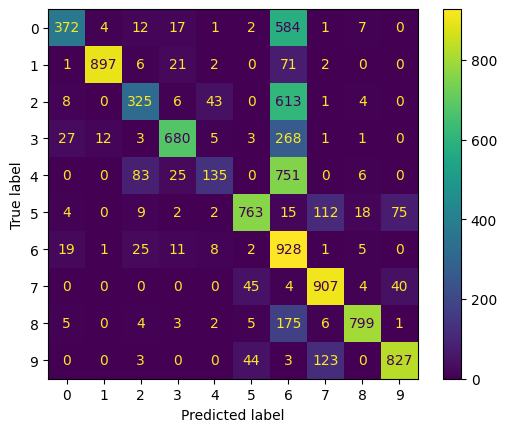

(0.6633, 0.7861523645051195)

In [77]:
x_train_ova_unbalanced, x_test_ova_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_ova_unbalanced = flattening(x_train_ova_unbalanced)
x_test_ova_unbalanced = flattening(x_test_ova_unbalanced)

ova_unbalanced = One_vs_All(15)
ova_unbalanced.fit(x_train_ova_unbalanced,y_unbalanced_set)
y_pred_unbalanced_ova = ova_unbalanced.predict(x_test_ova_unbalanced)

evaluation(y_pred_unbalanced_ova,y_test_full)

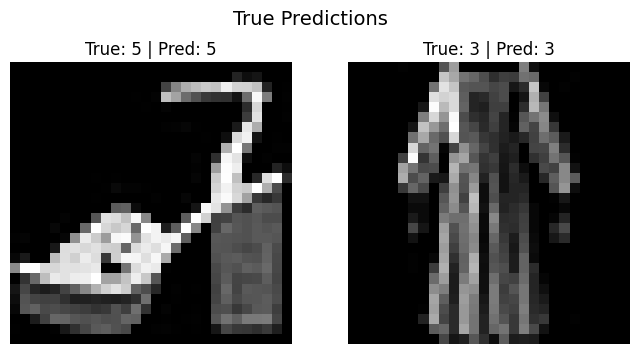

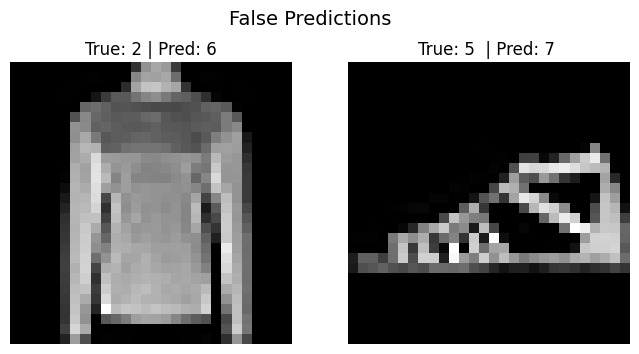

In [83]:
plot_and_save_analysis(y_test_full, y_pred_unbalanced_ova,x_flat,"ova_unbalanced",2,6,5,7)

## Multiclass Perceptron

 Accuracy Score: 0.6482
 Recall per class: [0.347 0.874 0.119 0.758 0.205 0.72  0.948 0.784 0.792 0.935]
 Precision per class: [0.89664083 0.99544419 0.82068966 0.8284153  0.65286624 0.89330025
 0.26562062 0.87597765 0.86180631 0.79778157]
 Macro Precision: 0.7888542620941349


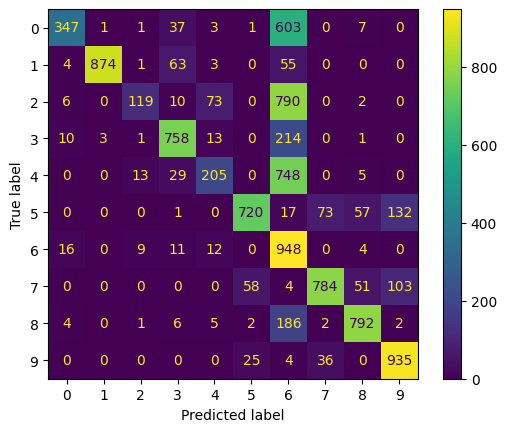

(0.6482, 0.7888542620941349)

In [78]:
x_train_multiclass_unbalanced, x_test_multiclass_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_multiclass_unbalanced = flattening(x_train_multiclass_unbalanced)
x_test_multiclass_unbalanced = flattening(x_test_multiclass_unbalanced)

multiclass_unbalanced = multiPerceptron(15)
multiclass_unbalanced.fit(x_train_multiclass_unbalanced,y_unbalanced_set)
y_pred_unbalanced_multiclass = multiclass_unbalanced.predict(x_test_multiclass_unbalanced)

evaluation(y_pred_unbalanced_multiclass,y_test_full)

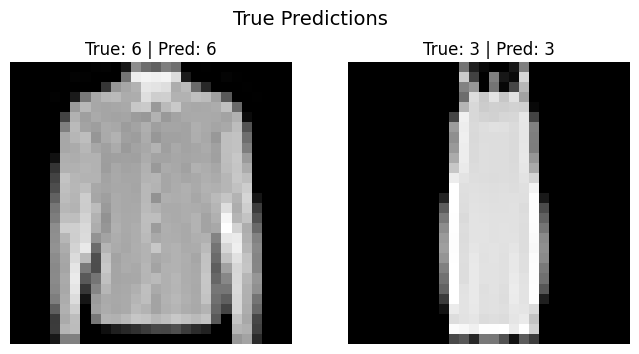

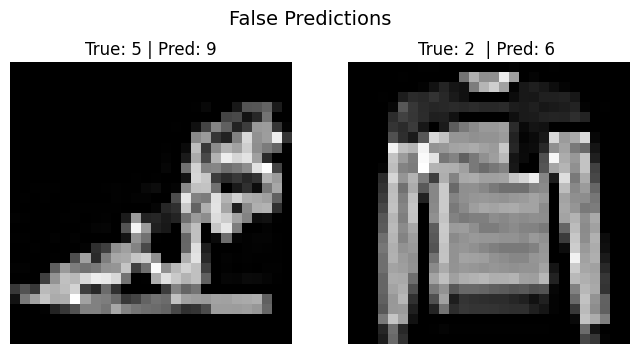

In [84]:
plot_and_save_analysis(y_test_full,y_pred_unbalanced_multiclass,x_flat,"multiclass_unbalanced",5,9,2,6)

# Unbalanced Dataset Using class Weights

In [32]:
weights = np.array([20,20,20,20,20,20,1,20,20,20])

## One vs One

 Accuracy Score: 0.7236
 Recall per class: [0.674 0.912 0.616 0.793 0.435 0.904 0.603 0.871 0.901 0.527]
 Precision per class: [0.75139353 0.98808234 0.63702172 0.79859013 0.62054208 0.79090114
 0.41216678 0.64806548 0.87731256 0.97232472]
 Macro Precision: 0.7496400482742274


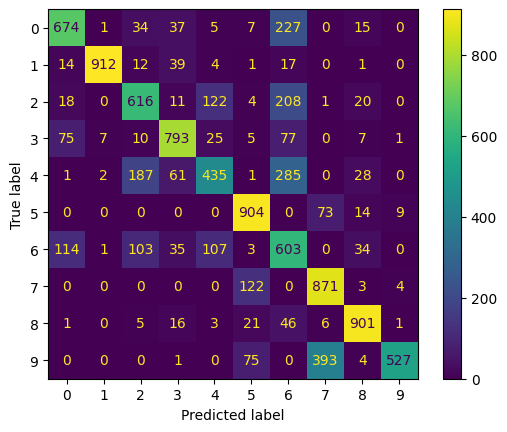

(0.7236, 0.7496400482742274)

In [33]:
x_train_ovo_unbalanced, x_test_ovo_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_ovo_unbalanced = flattening(x_train_ovo_unbalanced)
x_test_ovo_unbalanced = flattening(x_test_ovo_unbalanced)

pca = PCA(n_components=0.90)
x_train_ovo_unbalanced = pca.fit_transform(x_train_ovo_unbalanced)
x_test_ovo_unbalanced = pca.transform(x_test_ovo_unbalanced)

ovo_unbalanced = One_vs_One(15)
ovo_unbalanced.fit(x_train_ovo_unbalanced,y_unbalanced_set,weights=weights)
y_pred_unbalanced_ovo = ovo_unbalanced.predict(x_test_ovo_unbalanced)

evaluation(y_pred_unbalanced_ovo,y_test_full)

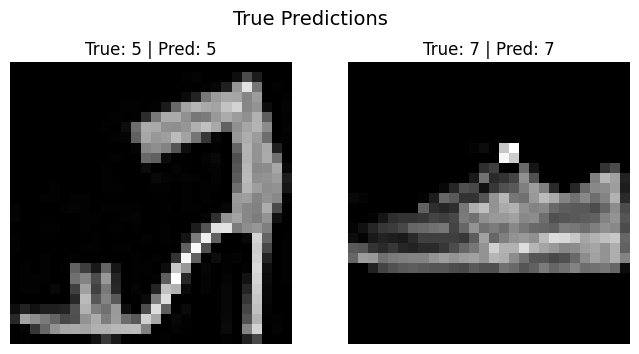

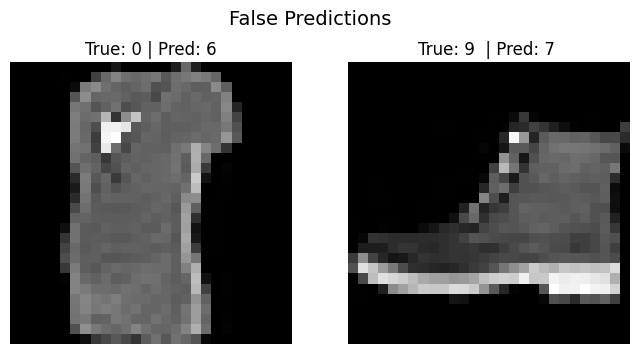

In [34]:
plot_and_save_analysis(y_test_full,y_pred_unbalanced_ovo,x_flat,"one_vs_one_unbalanced_cw",0,6,9,7)

## One vs All

 Accuracy Score: 0.6694
 Recall per class: [0.459 0.876 0.293 0.631 0.879 0.69  0.549 0.696 0.811 0.81 ]
 Precision per class: [0.83759124 0.99658703 0.79403794 0.89503546 0.4313052  0.89726918
 0.3250444  0.85294118 0.63707777 0.88621444]
 Macro Precision: 0.7553103847403363


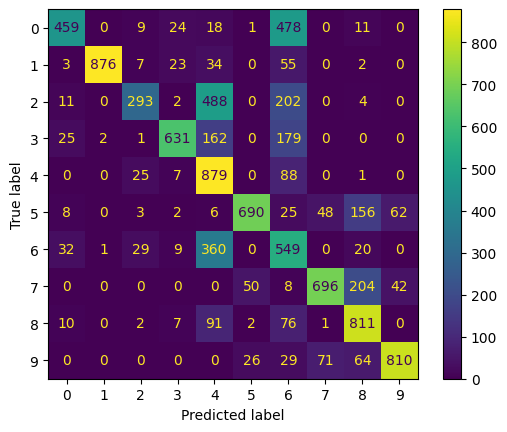

(0.6694, 0.7553103847403363)

In [ ]:

weights = np.array([20,20,20,20,20,20,1,20,20,20])
x_train_ova_unbalanced, x_test_ova_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_ova_unbalanced = flattening(x_train_ova_unbalanced)
x_test_ova_unbalanced = flattening(x_test_ova_unbalanced)

ova_unbalanced = One_vs_All(15)
ova_unbalanced.fit(x_train_ova_unbalanced,y_unbalanced_set,weights=weights)
y_pred_unbalanced_ova = ova_unbalanced.predict(x_test_ova_unbalanced)

evaluation(y_pred_unbalanced_ova,y_test_full)

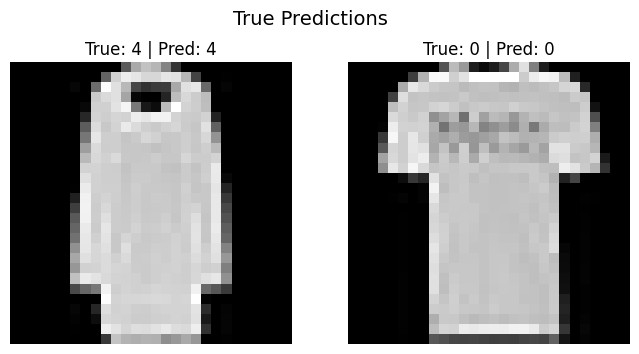

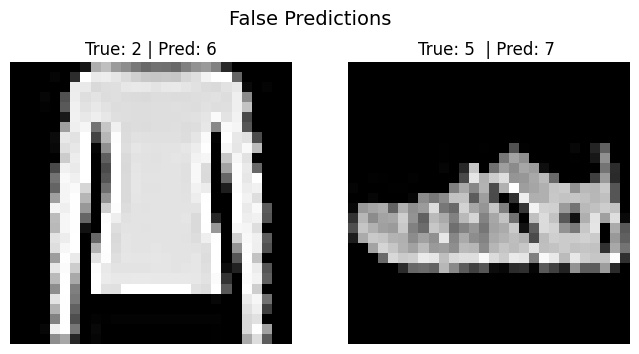

In [36]:
plot_and_save_analysis(y_test_full, y_pred_unbalanced_ova,x_flat,"ova_unbalanced_cw",2,6,5,7)

## Multiclass Perceptron

 Accuracy Score: 0.7477
 Recall per class: [0.643 0.919 0.732 0.884 0.49  0.651 0.433 0.845 0.952 0.928]
 Precision per class: [0.86424731 0.98078975 0.56612529 0.72399672 0.65333333 0.93133047
 0.54057428 0.82198444 0.70570793 0.78777589]
 Macro Precision: 0.7575865426907545


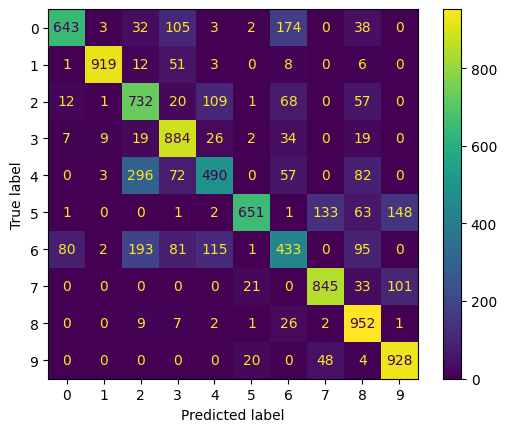

(0.7477, 0.7575865426907545)

In [49]:
weights = np.array([20,20,20,20,20,20,1,20,20,20])

x_train_multiclass_unbalanced, x_test_multiclass_unbalanced= norm(x_unbalanced_set,x_test_full)

x_train_multiclass_unbalanced = flattening(x_train_multiclass_unbalanced)
x_test_multiclass_unbalanced = flattening(x_test_multiclass_unbalanced)

multiclass_unbalanced = multiPerceptron(15)
multiclass_unbalanced.fit(x_train_multiclass_unbalanced,y_unbalanced_set,weights=weights)
y_pred_unbalanced_multiclass = multiclass_unbalanced.predict(x_test_multiclass_unbalanced)

evaluation(y_pred_unbalanced_multiclass,y_test_full)

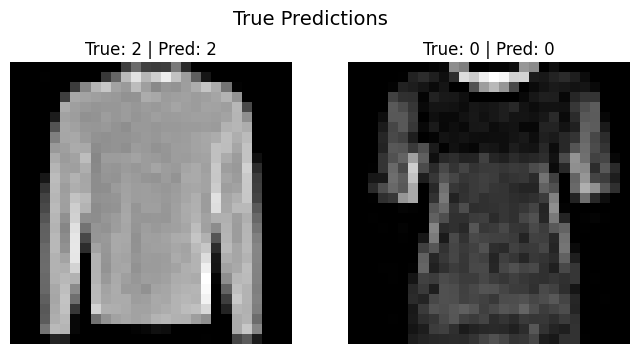

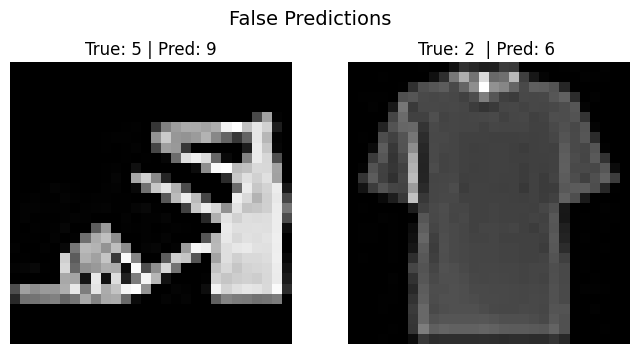

In [50]:
plot_and_save_analysis(y_test_full,y_pred_unbalanced_multiclass,x_flat,"multiclass_unbalanced_cw",5,9,2,6)

# Average Perceptron

## One vs One

 Accuracy Score: 0.8468
 Recall per class: [0.816 0.955 0.738 0.869 0.771 0.928 0.567 0.931 0.952 0.941]
 Precision per class: [0.79843444 0.97151577 0.75306122 0.83638114 0.73992322 0.93642785
 0.62444934 0.90917969 0.93424926 0.94858871]
 Macro Precision: 0.8452210646117042


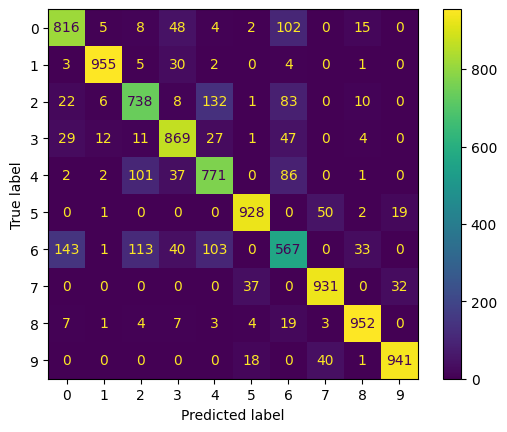

(0.8468, 0.8452210646117042)

In [60]:
x_train_full_pca, x_test_full_pca= norm(x_train_full,x_test_full)

x_train_full_pca = flattening(x_train_full_pca)
x_test_full_pca = flattening(x_test_full_pca)

pca = PCA(n_components=0.90)
x_train_full_pca = pca.fit_transform(x_train_full_pca)
x_test_full_pca = pca.transform(x_test_full_pca)

ovo_pca_full = One_vs_One(15,"averaged")
ovo_pca_full.fit(x_train_full_pca,y_train_full)
y_pred_pca_full = ovo_pca_full.predict(x_test_full_pca)

evaluation(y_pred_pca_full,y_test_full)

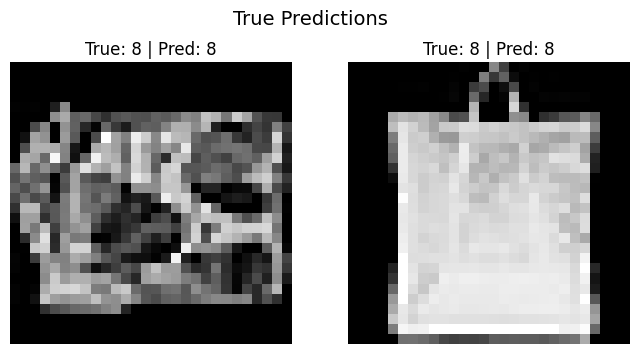

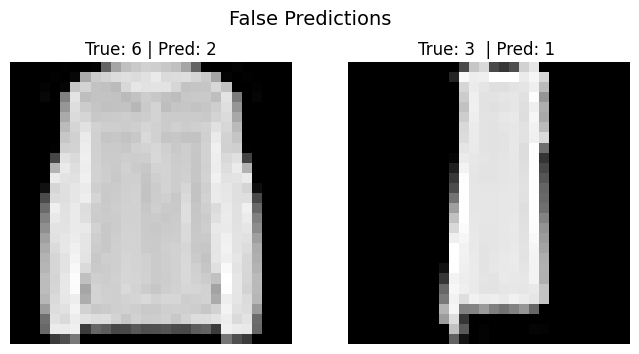

In [64]:
plot_and_save_analysis(y_test_full,y_pred_pca_full,x_flat,"ovo_averaged",6,2,3,1)

## One vs All

 Accuracy Score: 0.8417
 Recall per class: [0.817 0.956 0.73  0.874 0.774 0.906 0.524 0.936 0.951 0.949]
 Precision per class: [0.80176644 0.95695696 0.72709163 0.81758653 0.72067039 0.94769874
 0.65994962 0.90434783 0.91354467 0.94053518]
 Macro Precision: 0.8390147993596164


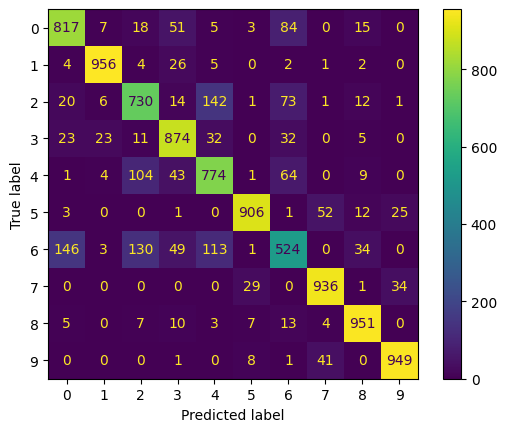

(0.8417, 0.8390147993596164)

In [63]:
x_train_full_ova_flat, x_test_full_ova_flat= norm(x_train_full,x_test_full)

x_train_full_ova_flat = flattening(x_train_full_ova_flat)
x_test_full_ova_flat = flattening(x_test_full_ova_flat)

ova_full = One_vs_All(15,mode="averaged")

ova_full.fit(x_train_full_ova_flat,y_train_full)
y_pred_ova_full = ova_full.predict(x_test_full_ova_flat)

evaluation(y_pred_ova_full,y_test_full)

## Multiclass Perceptron

### Averaged

 Accuracy Score: 0.844
 Recall per class: [0.812 0.958 0.73  0.866 0.773 0.916 0.549 0.942 0.942 0.952]
 Precision per class: [0.80316518 0.97160243 0.72709163 0.82085308 0.72446111 0.95218295
 0.6443662  0.9127907  0.92262488 0.94257426]
 Macro Precision: 0.8421712419040702


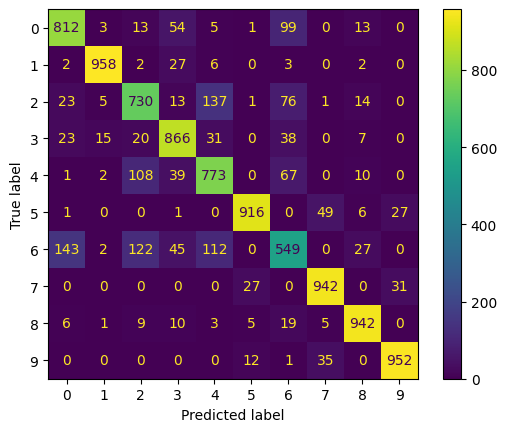

(0.844, 0.8421712419040702)

In [ ]:
epochs = 15
x_train_full_mclass, x_test_full_mclass= norm(x_train_full,x_test_full)

x_train_full_mclass = flattening(x_train_full_mclass)
x_test_full_mclass = flattening(x_test_full_mclass)

multi_perceptron_full = multiPerceptron(epochs,mode="averaged")
multi_perceptron_full.fit(x_train_full_mclass,y_train_full)
y_pred_full_multiclass = multi_perceptron_full.predict(x_test_full_mclass)

evaluation(y_pred_full_multiclass,y_test_full)

### Pocket

 Accuracy Score: 0.8118
 Recall per class: [0.801 0.942 0.781 0.902 0.522 0.903 0.481 0.946 0.971 0.869]
 Precision per class: [0.80827447 0.9822732  0.66298812 0.74854772 0.7756315  0.88965517
 0.62711864 0.87430684 0.78243352 0.97750281]
 Macro Precision: 0.8128731994689083


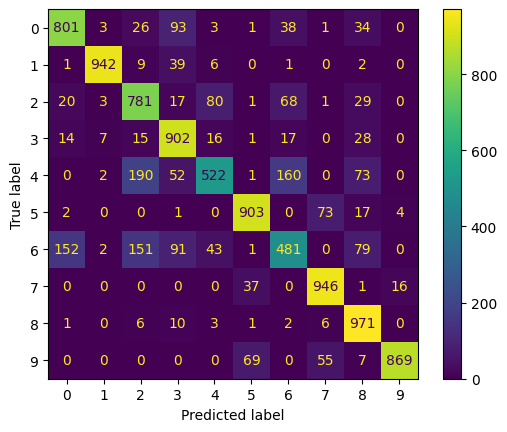

(0.8118, 0.8128731994689083)

In [15]:
epochs = 15

x_train_full_mclass , x_val , y_train_full, y_val = train_test_split(x_train_full,y_train_full,test_size=0.10,stratify=y_train_full)

x_train_full_mclass, x_test_full_mclass= norm(x_train_full_mclass,x_test_full)
x_val,_ = norm(x_val,x_val)
x_train_full_mclass = flattening(x_train_full_mclass)
x_test_full_mclass = flattening(x_test_full_mclass)
x_val = flattening(x_val)

multi_perceptron_full = multiPerceptron(epochs,mode="pocket")
multi_perceptron_full.fit(x_train_full_mclass,y_train_full,x_val,y_val)
y_pred_full_multiclass = multi_perceptron_full.predict(x_test_full_mclass)

evaluation(y_pred_full_multiclass,y_test_full)

### Hybrid

 Accuracy Score: 0.8403
 Recall per class: [0.862 0.958 0.774 0.854 0.709 0.913 0.512 0.917 0.944 0.96 ]
 Precision per class: [0.74761492 0.97456765 0.69230769 0.83972468 0.75828877 0.94807892
 0.65894466 0.91243781 0.93096647 0.92753623]
 Macro Precision: 0.8390467801694458


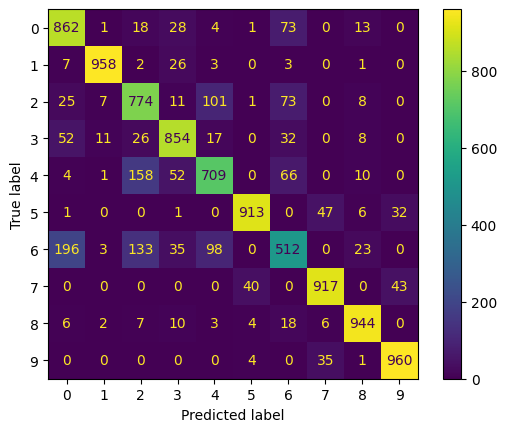

(0.8403, 0.8390467801694458)

In [14]:
epochs = 15

x_train_full_mclass , x_val , y_train_full, y_val = train_test_split(x_train_full,y_train_full,test_size=0.10,stratify=y_train_full)

x_train_full_mclass, x_test_full_mclass= norm(x_train_full_mclass,x_test_full)
x_val,_ = norm(x_val,x_val)
x_train_full_mclass = flattening(x_train_full_mclass)
x_test_full_mclass = flattening(x_test_full_mclass)
x_val = flattening(x_val)

multi_perceptron_full = multiPerceptron(epochs,mode="hybrid")
multi_perceptron_full.fit(x_train_full_mclass,y_train_full,x_val,y_val)
y_pred_full_multiclass = multi_perceptron_full.predict(x_test_full_mclass)

evaluation(y_pred_full_multiclass,y_test_full)